# SVM. Метод опорных векторов + Кросс-валидация

В этом задании вы попрактикуетесь в применении метода опорных векторов, а также примените кросс-валидацию для подбора гиперпараметров и оценки качества моделей!

## Данные

В этой практической работе мы будем обучать модели машинного обучения, ставить эксперименты, подбирать гиперпараметры и сравнивать модели. Вам предлагается решить задачу бинарной классификации, а именно построить алгоритм, определяющий превысит ли средний заработок человека порог $50k. Каждый объект выборки — человек, для которого известны следующие признаки:
 - `age`
 - `workclass`
 - `fnlwgt`
 - `education`
 - `education-num`
 - `marital-status`
 - `occupation`
 - `relationship`
 - `race`
 - `sex`
 - `capital-gain`
 - `capital-loss`
 - `hours-per-week`

Более подробно про признаки можно почитать [здесь](http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names). Целевой признак записан в переменной *>50K,<=50K*.

## Бонус ноутбука

Все исследователи данных знают, что SVM из библиотеки `sklearn` работает крайне медленно, поэтому на практике не могут его применять для решения задач.

В этом ноутбуке мы используем средства библиотеки `sklearn intelex` для ускорения обучения SVM в 600 раз!

Ради интереса попробуйте после завершения выполнения заданий в ноутбуке удалить ячейки, связанные с установкой и импортом `sklearn intelex` и засечь время работы методов :)

In [58]:
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [59]:
import pandas as pd
import numpy as np
import sys
import os
import site

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from matplotlib import pyplot as plt

sys.path.append(os.path.join(os.path.dirname(site.getsitepackages()[0]), "site-packages"))

## Метрика качества

В задании мы будем оценивать качество моделей с помощью метрики *AUC-ROC*.

Загрузим набор данных `data.adult.csv`.

In [60]:
df = pd.read_csv("https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/data.adult.csv")

df[:5]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K


Иногда в данных встречаются пропуски. Как задаются пропуски обычно либо прописывается в описании к данным, либо просто на месте пропуска после чтения данных оказывается значение `numpy.nan`.  
Более подробно о работе с пропусками в Pandas можно прочитать например [здесь](http://pandas.pydata.org/pandas-docs/stable/missing_data.html).

В данном датасете пропущенные значения обозначены как "?".

### Задание

Найдите все признаки, имеющие пропущенные значения.

Затем удалите из выборки все объекты с пропусками.

In [61]:
df.shape

(16280, 14)

In [62]:
# your code here
(df=='?').sum()

age                 0
workclass         929
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        933
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
>50K,<=50K          0
dtype: int64

In [63]:
# your code here
df = df[df['workclass'] != '?']
df = df[df['occupation'] != '?']

df.shape

(15347, 14)

### Задание

Cколько столбцов содержит матрица `X`?

Постройте гистограммы для признаков `age`, `fnlwgt`, `capital-gain`. Глядя на получившиеся графики в чем заключается особенность данных? На какие алгоритмы это может повлиять? Может ли масшитабирование повлиять на работу этих алгоритмов?

Ответьте на этот вопрос для себя устно.

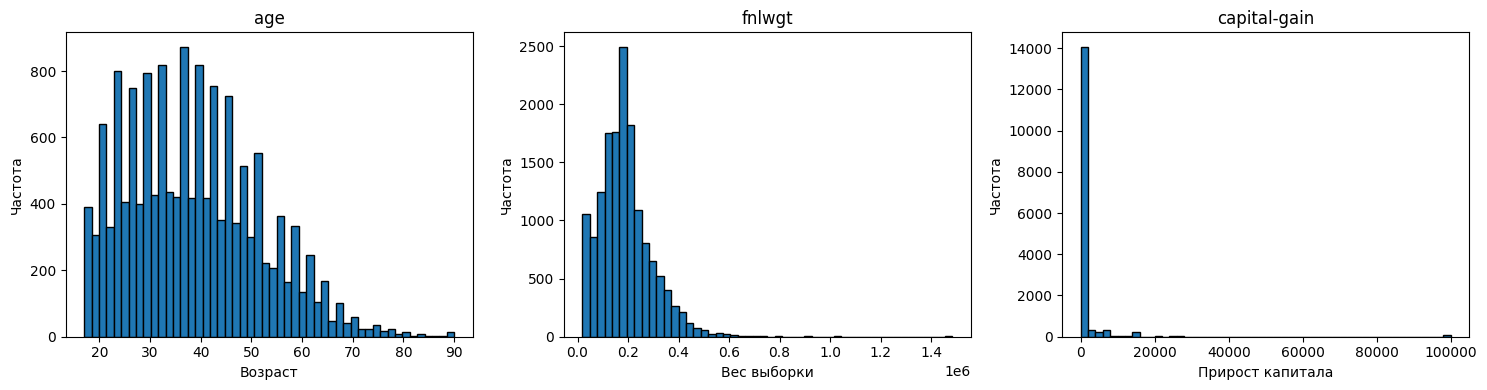

In [64]:
# your code here
# Построим гистограммы для признаков age, fnlwgt, capital-gain
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['age'], bins=50, edgecolor='black')
axes[0].set_title('age')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Частота')

axes[1].hist(df['fnlwgt'], bins=50, edgecolor='black')
axes[1].set_title('fnlwgt')
axes[1].set_xlabel('Вес выборки')
axes[1].set_ylabel('Частота')

axes[2].hist(df['capital-gain'], bins=50, edgecolor='black')
axes[2].set_title('capital-gain')
axes[2].set_xlabel('Прирост капитала')
axes[2].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Особенность: признаки имеют разный масштаб, что влияет на SVM
# Масштабирование необходимо для SVM!

Масштабируйте все вещественные признаки (масштабированную матрицу назовите, как и раньше, `X`).

In [65]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', '>50K,<=50K']


In [66]:
from sklearn.preprocessing import StandardScaler

y = (df['>50K,<=50K']=='>50K').astype(int)
x = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
x = scaler.fit_transform(x)

x.shape

(15347, 6)

## Обучение классификаторов на вещественных признаках

В данном разделе необходимо будет работать только с вещественными признаками и целевой переменной.

В этом задании необходимо проверять качество алгоритмов по кросс-валидации. Напомним, что это за процесс.


### Кросс-валидация [обучающий текст]

Разбивать данные на train-test как мы делали раньше - неплохой подход. Однако при этом подходе мы привязываем и обучение модели, и оценку качества к конкретному разбиению, а для другого разбиения можем получить модель совершенно другого качества, что плохо.

Поэтому хочется оценить качество модели без привязки к конкретному разбиению на train-test. Для этого все обучающие данные разбиваются на несколько равных блоков (фолдов), и затем модель обучается несколько раз:
* первый раз - на всех блоках, кроме 1-го, а качество оценивается на 1-м блоке
* второй раз - на всех блоках, кроме 2-го, а качество оценивается на 2-м блоке и так далее
Для оценки качества модели полученные значения метрик на тестовых блоках усредняются - это называется *k-fold кросс-валидацией*.

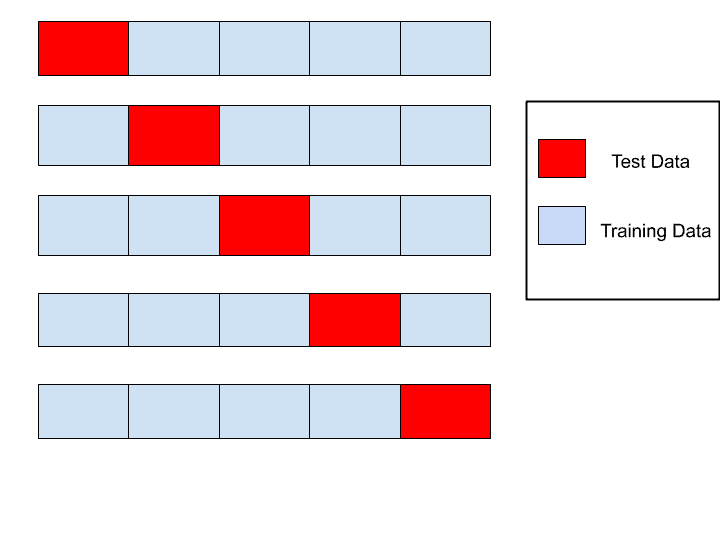

Сначала обучите по кросс-валидации c **тремя** фолдами и метрикой **roc_auc** алгоритмы:
*  LogisticRegression
*  SVC(kernel='linear')

Остальные параметры оставьте по умолчанию.

In [67]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# пример для логистической регрессии
print(cross_val_score(LogisticRegression(), x, y, cv=3, scoring='roc_auc', verbose=2).mean())

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
0.8250512541054421


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [68]:
# посмотрите на среднее качество SVM с линейным ядром

# your code here
print(cross_val_score(SVC(kernel='linear'), x, y, cv=3, scoring='roc_auc', verbose=2).mean())

[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.2s
[CV] END .................................................... total time=   0.5s
0.8004062650728304


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.0s finished


### Задание

Чему равно качество наилучшей из этих моделей?  
Ответ округлите до десятых.

In [69]:
svm=cross_val_score(SVC(kernel='linear'), x, y, cv=3, scoring='roc_auc', verbose=2).mean()
lr =cross_val_score(LogisticRegression(), x, y, cv=3, scoring='roc_auc', verbose=2).mean()
print(max(svm, lr))

[CV] END .................................................... total time=   1.3s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
0.8250512541054421


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Теперь посмотрим как влияет подбор гиперпараметров на качество предсказания моделей. Сейчас и далее будем рассматривать два алгоритма:
 - Logistic Regression
 - SVC (Support Vector Classifier)

У обоих алгоритмов будем оптимизировать гиперпараметр С, а у SVC - ещё гиперпараметр kernel.

*  Ищите C в диапазоне от 0.01 до 10.01 с шагом 0.25
*  Перебирайте ядра из списка ['rbf','poly','sigmoid','linear']

### Подбор гиперпараметров по сетке (GridSearchCV) [обучающий текст]

Раз уж мы начали использовать кросс-валидацию, то будем использовать ее по-максимуму. Для подбора гиперпараметров модели также можно применить этот подход вместо разбиения на train и test.

Идея подбора гиперпараметров по сетке:

* задаем список перебираемых значений гиперпараметров (можно подбирать одновременно несколько гиперпараметров)

* для каждого набора значений гиперпараметров вычисляем качество модели по кросс-валидации

* итоговый ответ - это набор значений гиперпараметров, для которого модель имеет наибольшее качество на кросс-валидации.

Метод, реализующий эту схему, называется GridSearchCV.

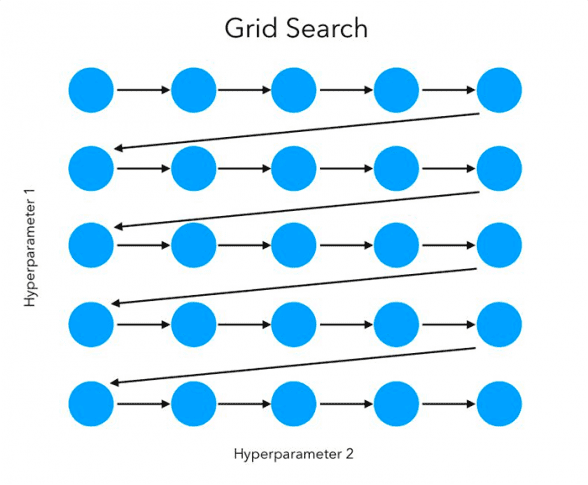

Для подбора гиперпараметров воспользуйтесь перебором по сетке, который реализован в классе GridSearchCV. В качестве схемы кросс-валидации используйте 3-fold cv.

Покажем пример использования GridSearchCV.

In [70]:
# подберите C у логистической регрессии

from sklearn.model_selection import GridSearchCV

params = {'C' : [1, 2, 3]} # задаем словарь параметров и список перебираемых значений - в данном случае ищем C из списка [1,2,3]

gs = GridSearchCV(LogisticRegression(), params, cv=3, scoring='roc_auc')
# первый параметр - модель, второй - словарь параметров, третий - число фолдов, четвертый - метрика

gs.fit(x, y) # применяем метод к данным X, y (GridSearchCV сам разобъет данные на фолды)

print(gs.best_score_) # качество наилучшей модели (с оптимальными гиперпараметрами)
print(gs.best_params_) # оптимальные гиперпараметры

0.8250512541054421
{'C': 1}


Подбор гиперпараметров для логистической регрессии

In [71]:
# your code here
params = {'C':np.arange(0.01,10.02,0.25)}
logreg = GridSearchCV(LogisticRegression(), params, cv=3, scoring='roc_auc')
logreg.fit(x,y)
print(f'Лучшее качество: {logreg.best_score_}')
print(f'Оптимальные гиперпараметры: {logreg.best_params_}')

Лучшее качество: 0.8251101327241286
Оптимальные гиперпараметры: {'C': np.float64(0.26)}


In [72]:
# Шаг 1: Подбор ядра
params_kernel = {'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}

kernels = GridSearchCV(SVC(), params_kernel, cv=3, scoring='roc_auc')
kernels.fit(x, y)

print(f"Лучшее ядро: {kernels.best_params_}")
best_kernel = kernels.best_params_['kernel']

# Шаг 2: Подбор C для лучшего ядра
params_C = {'C': np.arange(0.01, 2.02, 0.25), 'kernel': [best_kernel]}

svc = GridSearchCV(SVC(), params_C, cv=3, scoring='roc_auc')
svc.fit(x, y)

print(f"SVC - Лучший ROC-AUC: {svc.best_score_:.4f}")
print(f"SVC - Лучшие параметры: {svc.best_params_}")

Лучшее ядро: {'kernel': 'rbf'}
SVC - Лучший ROC-AUC: 0.8145
SVC - Лучшие параметры: {'C': np.float64(0.01), 'kernel': 'rbf'}


### Задание

Какой из алгоритмов имеет наилучшее качество?

Сравните алгоритмы с точки зрения времени обучения. Обучение какого из алгоритмов работает дольше всего и, как вы думаете, почему?

## Добавление категориальных признаков в модели

Пока мы не использовали нечисловые признаки, которые есть в датасете. Давайте посмотрим, правильно ли мы сделали и увеличится ли качество моделей после добавлениях этих признаков.

*  Преобразуйте все категориальные признаки (исходной матрицы df) с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [`pandas.get_dummies`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html). Чтобы избежать переобучения, в `get_dummies` поставьте гиперпараметр **`drop_first=True`**.

*  Заново масштабируйте данные

In [73]:
x_old = df.drop('>50K,<=50K', axis=1)

x_new = pd.get_dummies(x_old, drop_first=True)
x_new.head()

new_scaler = StandardScaler()
new_scaler = new_scaler.fit_transform(x_new)

print(f"Размер новой матрицы: {new_scaler.shape}")

Размер новой матрицы: (15347, 56)


Так как после кодирования признаков получилось достаточно много, в этой работе мы не будем добавлять их и подбирать заново оптимальные гиперпараметры.

Обучите алгоритмы с наилучшими гиперпараметрами из предыдущего пункта. Дало ли добавление новых признаков прирост качества? Измеряйте качество как и раньше используя 3-Fold CV в функции `cross_val_score`.

In [74]:
#your code here
new_logreg = cross_val_score(LogisticRegression(**gs.best_params_), new_scaler, y, cv=3, scoring='roc_auc').mean()
print(f'ROC-AUC LogReg с категориальными: {new_logreg}')
new_svc = cross_val_score(SVC(**svc.best_params_), new_scaler, y ,cv=3, scoring='roc_auc').mean()
print(f'ROC-AUC SVM с категориальными: {new_svc}')



ROC-AUC LogReg с категориальными: 0.9025951725835925
ROC-AUC SVM с категориальными: 0.8762295755248912


In [75]:

#your code here
print(f'Прирост качетсва LR: {new_logreg - logreg.best_score_}')
print(f'Прирост качетсва SVM: {new_svc - svc.best_score_}')

Прирост качетсва LR: 0.07748503985946387
Прирост качетсва SVM: 0.06174925360291983


Отличается ли теперь наилучший классификатор от наилучшего в предыдущем пункте?

### Задание

*  Разбейте данные на тренировочную и тестовую часть (либо данные только с числовыми признаками, либо данные после OneHot-кодировки - в зависимости от того, на каких данных модели лучше отработали).

**Вопрос:**  
стали ли модели лучше решать задачу при добавлении закодированных категориальных признаков?

*test_size = 0.25, random_state = 42*

* Cреди всех обученных в работе моделей возьмите наилучшую (по roc-auc).
Заново обучите эту модель на тренировочных данных, сделайте предсказание на тесте.

* Постройте roc-кривую и отметьте на ней значение roc-auc - по тестовым данным.

In [76]:
from sklearn.model_selection import train_test_split

#your code here
xtrain, xtest, ytrain, ytest = train_test_split(new_scaler, y, test_size=0.25, random_state=42)

print(f'Размер трейна: {xtrain.shape}, размер теста: {xtest.shape}')

all_scores = {'lr_old': logreg.best_score_,
              'lr_new': new_logreg,
              'SVC_old': svc.best_score_,
              'SVC_new': new_svc}
best_model_name = max(all_scores, key=all_scores.get)
print(f'Лучшая модель: {best_model_name}: {all_scores[best_model_name]}')

Размер трейна: (11510, 56), размер теста: (3837, 56)
Лучшая модель: lr_new: 0.9025951725835925


In [77]:
if 'lr' in best_model_name:
    best_model = LogisticRegression(**logreg.best_params_)
else:
    best_model = SVC(**svc.best_params_)

best_model.fit(xtrain, ytrain)

pred_proba = best_model.predict_proba(xtest)[:,1]
pred_proba[:10]

array([0.04528302, 0.05172867, 0.71710313, 0.07656781, 0.00419087,
       0.69443185, 0.01039244, 0.46297986, 0.46550019, 0.06251693])

AUC на тесте: 0.9046202310115506


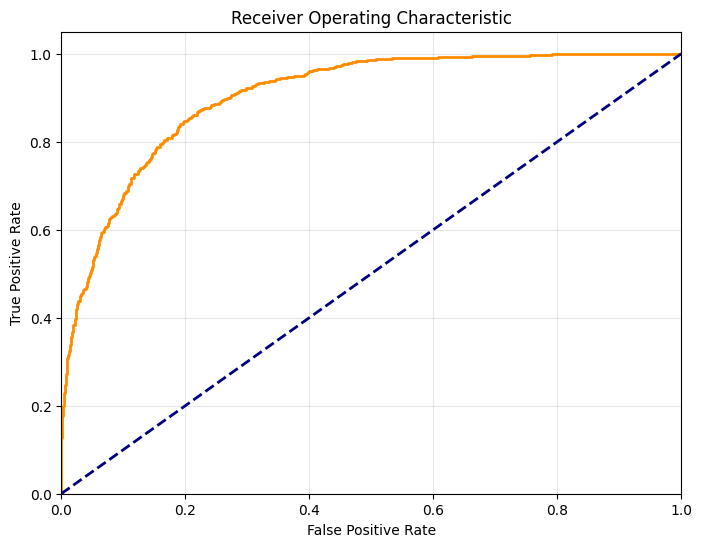

In [78]:
from sklearn.metrics import roc_curve, auc

#your code here
fpr, tpr, threshold = roc_curve(ytest, pred_proba)
roc_auc = auc(fpr, tpr)

print(f'AUC на тесте: {roc_auc}')

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.grid(alpha=0.3)
plt.show()

### Задание

Чему равен `roc-auc` наилучшей модели на тестовых данных?